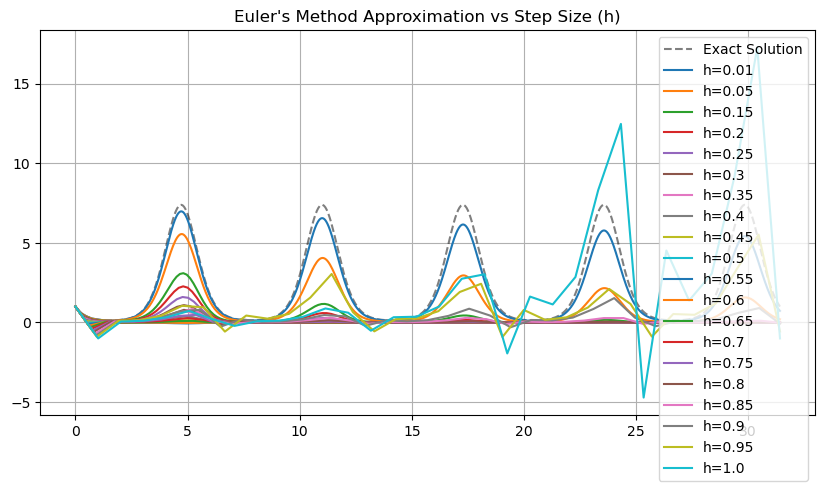

In [56]:
import numpy as np
import matplotlib.pyplot as plt
# Define parameters
steps = [0.01, 0.05, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
x_start, x_end = 0, 10*np.pi
h1 = steps[0] # 0.01 
results = []
avgerrors = []
x_15_localerror = []

# Function representing dy/dx = -2y*cos(x)
def f(x, y):
    return -2 * y * np.cos(x)

def exact(x):
    return np.exp(-2 * np.sin(x))

for h in steps :
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    # Initial condition
    y_values[0] = 1 # y(0) = 1
    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    #plot 1 
    y_exact = exact(x_values)
    errors = np.abs(y_values - y_exact)

    #plot 2
    results.append((x_values, y_values, h))
    avgerrors.append(np.mean(errors))

    #plot 3
    idx_15 = (np.abs(x_values - 15)).argmin()
    x_15_localerror.append((h, errors[idx_15]))
    
    # Plot the results
plt.figure(figsize=(10, 5))
xplot = np.linspace(x_start, x_end, 500)
plt.plot(xplot, exact(xplot), 'k--', label='Exact Solution', alpha=0.5)
for x_vals, y_vals, h in results:
    plt.plot(x_vals, y_vals, label=f'h={h}')
plt.title("Euler's Method Approximation vs Step Size (h)")
plt.legend()
plt.grid(True)

# The errors appear to be increasing as the step size increases. This makes sense, as higher step sizes causes the slope at different points to be more and more inaccurate as the step sizes increase, causing each subsequent y to also be off.

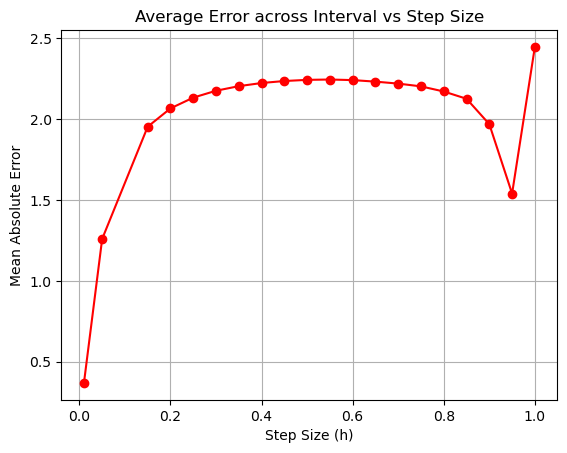

In [57]:
#plot 2 code
plt.plot(steps, avgerrors, 'o-', color='red')
plt.xlabel('Step Size (h)')
plt.ylabel('Mean Absolute Error')
plt.title('Average Error across Interval vs Step Size')
plt.grid(True)

# The average error is increasing.

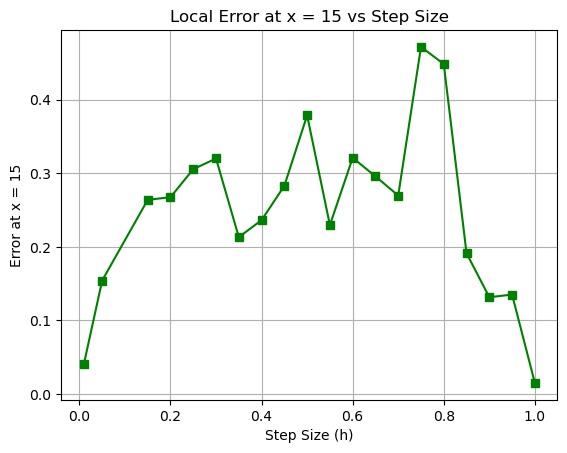

In [58]:
#plot 3 code
h, errorat15 = zip(*x_15_localerror)
plt.plot(h, errorat15, 's-', color='green')
plt.xlabel('Step Size (h)')
plt.ylabel('Error at x = 15')
plt.title('Local Error at x = 15 vs Step Size')
plt.grid(True)

# The local error increases and then decreases.

## For plot 1, the results make sense. The error is very small at h = 0.01, where the approximation is able to track the oscillatory nature of the function closely. This then unravels as the step sizes get larger, resulting in the curves deviating from the function itself as it begins to overshoot and undershoot. This carries over into plot 2, where the average error for each step generally increases, following the logic in plot 1.

## For plot 2, the error is initially very small, then grows as the errors accumulate over time due to the step sizes. However, as the step sizes approach 1, the error actually decreases, which reflects the fact that the step size actually lands closer and closer to 15, resulting in a reduction in the error. This is reflected in plot 1, and even though the overall curve is very inaccurate, it manages to land on the exact solution at 15 because the step size lines up with the x value.

In [59]:
#code for finding lambda
def get_lambda(x):
    return -2 * np.cos(x)

#find local stability limits h <= 2 / |lambda(x)|
lambdas = get_lambda(x_vals)
with np.errstate(divide='ignore'):
    local_h_limits = 2 / np.abs(lambdas)

#global stability condition
global_h_limit = np.min(local_h_limits)

print(f"maximum lambda: {np.max(np.abs(lambdas)):.4f}")
print(f"stability condition: h <= {global_h_limit:.4f}")

maximum lambda: 2.0000
stability condition: h <= 1.0000


# since the maximum lambda is 2, stability is difficult to maintain. The stability condition occurs when h <= 1.0

# I used Gemini Pro to help me create the dataset and learn the usage of the zip function for plot 3. For the stability analysis, I used Claude to help me generate code that matches what is required to derive the stability analysis, including the with control structure.